---
# **Statistical Expansion vs. Neural Understanding: Advancing Financial Information Retrieval**
---

# **Setup & Data Loading**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import shutil

try:
    import pyterrier as pt
except ImportError:
    !pip install -q python-terrier
    import pyterrier as pt

if not pt.java.started():
    pt.java.init()

from pyterrier.measures import *

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.1/208.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.0/149.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 127.5 MB/s eta 0:00:00
terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


We use the `ir_datasets` integration within PyTerrier to load the **Financial Question Answering (FiQA)** dataset.

Specifically, we use the `beir/fiqa/test` subset, which is the designated benchmark for this project.

**Source:** [BEIR/FiQA Documentation](https://ir-datasets.com/beir.html#beir/fiqa)

The dataset object provides access to three main components: the document corpus, the queries (topics), and the relevance judgments (qrels).

In [ ]:
dataset = pt.get_dataset('irds:beir/fiqa/test')

### a) **Document Collection**

The **Document Collection** represents the corpus of data to be indexed.

In the context of FiQA, this includes a mix of heterogeneous financial texts, ranging from short microblogs (tweets) to snippets from financial reports and news headlines.

In [ ]:
for doc in dataset.get_corpus_iter():
    print(doc.keys())
    print(doc)
    break

[INFO] [starting] building docstore
[INFO] [starting] opening zip file
[INFO] If you have a local copy of https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip, you can symlink it here to avoid downloading it again: /root/.ir_datasets/downloads/17918ed23cd04fb15047f73e6c3bd9d9
[INFO] [starting] https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip
docs_iter:   0%|                                     | 0/57638 [00:00<?, ?doc/s]
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip: 0.0%| 0.00/17.9M [00:00<?, ?B/s]
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip: 0.2%| 32.8k/17.9M [00:00<01:16, 236kB/s]
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip: 0.5%| 81.9k/17.9M [00:00<01:02, 286kB/s]
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip: 1.1%| 197k/17.9M [00:00<00:39, 454kB/s] 
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/dat

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

dict_keys(['text', 'docno'])
{'text': "I'm not saying I don't like the idea of on-the-job training too, but you can't expect the company to do that. Training workers is not their job - they're building software. Perhaps educational systems in the U.S. (or their students) should worry a little about getting marketable skills in exchange for their massive investment in education, rather than getting out with thousands in student debt and then complaining that they aren't qualified to do anything.", 'docno': '3'}


### b) **Queries**

The **Queries** (or Topics) represent the information needs of users expressed in natural language.

These are the inputs our search engine will process to retrieve relevant documents.

In [ ]:
topics = dataset.get_topics()
display(topics)

[INFO] [starting] opening zip file
[INFO] [finished] opening zip file s]
[INFO] [starting] opening zip file
[INFO] [finished] opening zip file s]


,qid,query
0,4641,Where should I park my rainy-day / emergency f...
1,5503,Tax considerations for selling a property belo...
2,7803,Can the Delta be used to calculate the option ...
3,7017,Basic Algorithmic Trading Strategy
4,10152,What does a high operating margin but a small ...
...,...,...
643,4102,How can I determine if my rate of return is “g...
644,3566,Where can I buy stocks if I only want to inves...
645,94,Using credit card points to pay for tax deduct...
646,2551,How to find cheaper alternatives to a traditio...


### c) **Qrels**

The **Qrels** (Quality Relevance Assessments) contain the "ground truth" for the test set.

They map specific queries to relevant documents.

In [ ]:
qrels = dataset.get_qrels()
display(qrels)

,qid,docno,label,iteration
0,8,566392,1,0
1,8,65404,1,0
2,15,325273,1,0
3,18,88124,1,0
4,26,285255,1,0
...,...,...,...,...
1701,11039,330058,1,0
1702,11039,91183,1,0
1703,11054,155053,1,0
1704,11054,321015,1,0


---
---

# **Exploratory Data Analysis (EDA)**

Before designing specific retrieval strategies, we conduct an offline analysis of the dataset components to understand the context in which our search engine will operate.

This step is crucial for identifying potential challenges, such as vocabulary mismatch or data sparsity, and for guiding the design of our system.

We examine the document collection, the user queries, and the available relevance assessments to understand the characteristics of the data and how documents are judged in relation to information needs.

## a) **Document Collection Analysis**

We analyze the physical characteristics of the corpus, focusing on document length statistics.

This helps us hypothesize the distribution of data sources (e.g., distinguishing between short microblogs and longer financial reports) and determine necessary preprocessing steps.

In [ ]:
# Load the corpus into a Pandas DataFrame
docs_list = []
for doc in dataset.get_corpus_iter():
    docs_list.append(doc)

docs_df = pd.DataFrame(docs_list)
display(docs_df.head(10))

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

,text,docno
0,I'm not saying I don't like the idea of on-the...,3
1,So nothing preventing false ratings besides ad...,31
2,You can never use a health FSA for individual ...,56
3,Samsung created the LCD and other flat screen ...,59
4,Here are the SEC requirements: The federal sec...,63
5,"""Only relevant to those with fantasy economy t...",100
6,Futures contracts are a member of a larger cla...,108
7,This month when you join Scentsy you get a fre...,125
8,Whenever you pay or withdraw some fund from yo...,132
9,So you asked him in 2010 how he was gong to co...,138


- structure analysis

In [ ]:
# This prints one row as a dictionary, so you can see the full text of every column.
sample_row = docs_df.iloc[90]
for col, val in sample_row.items():
    print(f"[{col.upper()}]:\n{val}\n{'-'*40}")

[TEXT]:
"If the value of these hard assets is significant you probably have them insured, and for significant art work you should have had them appraised as part of getting them insured. Therefore the process of adding them into the net worth calculation would be trivial.  Your goals should be a mix of liquid assets, and assets that are harder to sell, such as real estate. It should also include those items you are more reluctant to sell. In some cases these ""investments"" do need to be included in official calculations, such as applying for a student loan or financial aid, required financial disclosure statements for some government jobs, or applications for government assistance."
----------------------------------------
[DOCNO]:
962
----------------------------------------


- basic statistics

In [ ]:
docs_df['doc_length'] = docs_df['text'].apply(lambda x: len(x.split()))
print(docs_df['doc_length'].describe())

empty_docs = docs_df[docs_df['doc_length'] == 0]
print(f"Number of Empty Documents: {len(empty_docs)}")

count    57638.000000
mean       132.904473
std        128.738342
min          0.000000
25%         57.000000
50%         90.000000
75%        159.000000
max       2973.000000
Name: doc_length, dtype: float64
Number of Empty Documents: 38


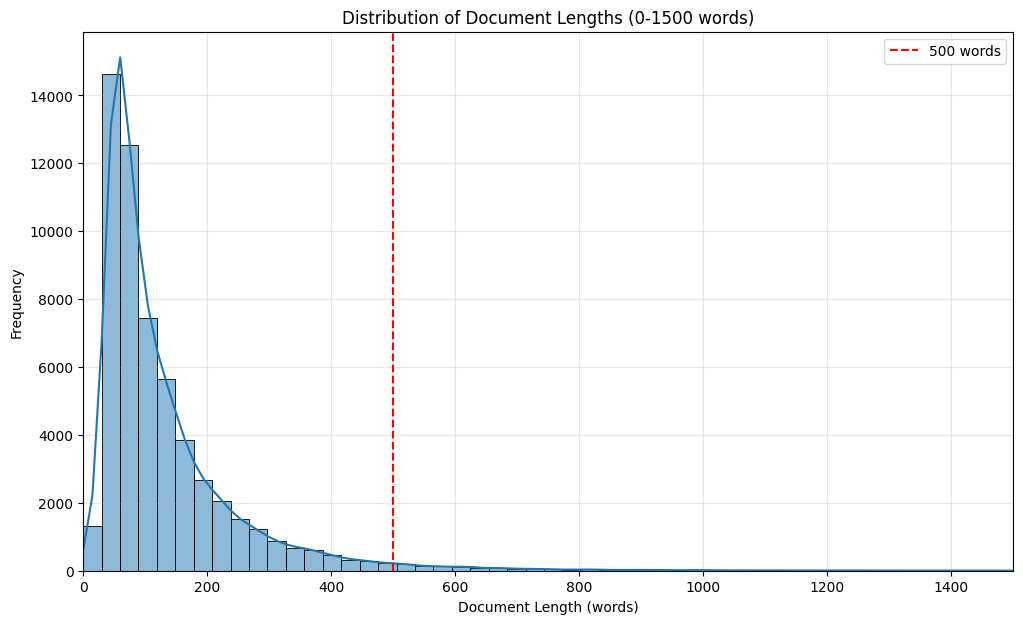

In [ ]:
# distribution of documents length
plt.figure(figsize=(12, 7)) # Increased figure size for better readability
sns.histplot(docs_df['doc_length'], bins=100, kde=True) # Increased bins for more detail
plt.title('Distribution of Document Lengths (0-1500 words)')
plt.xlabel('Document Length (words)')
plt.ylabel('Frequency')
plt.xlim(0, 1500) # Set x-axis limit to focus on relevant range and compress the tail
plt.axvline(x=500, color='red', linestyle='--', label='500 words') # Highlight 500-word mark
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The document collection contains highly varied documents. While there are 38 completely empty documents (with no words), others are very long (`maximum length: 2,973 words`).

This shows that the document length distribution has high variance (`spanning 0–3,000 word`s) and is right-skewed.

Even though empty documents are few (`38` out of 57,000), they must be filtered out during indexing.

- vocabulary analysis

In [ ]:
# We use a set comprehension for a quick estimate on the raw text)
vocab = set()
docs_df['text'].str.split().apply(vocab.update)
print(f"Approximate Vocabulary Size (unique terms): {len(vocab)}")

Approximate Vocabulary Size (unique terms): 262358


=== VOCABULARY ANALYSIS (Top 20 Words) ===
money: 30,696
just: 19,682
people: 19,155
don: 18,842
like: 18,726
tax: 17,757
pay: 17,377
time: 16,087
make: 15,970
company: 14,651
market: 13,748
need: 12,775
year: 12,156
price: 12,145
want: 12,036
account: 12,027
stock: 11,915
income: 11,782
business: 11,632
good: 11,275


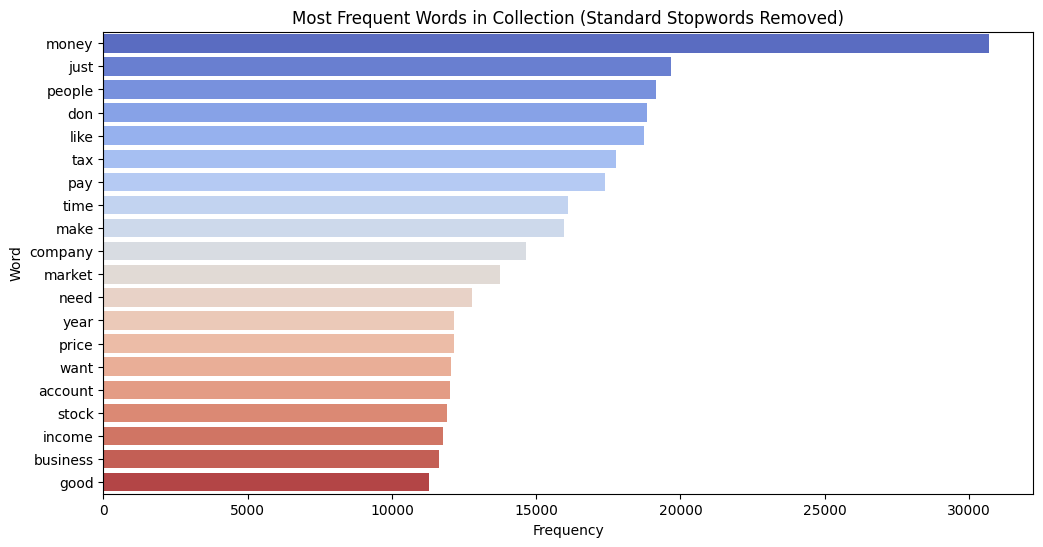

In [ ]:
# code from course material
# We use a standard IR tool (CountVectorizer) to remove standard "stopwords" (the, and, of).
from sklearn.feature_extraction.text import CountVectorizer

print("=== VOCABULARY ANALYSIS (Top 20 Words) ===")

# 1. Initialize vectorizer with Standard English stop words removed
# We only look at the top 20 most frequent words
vec = CountVectorizer(stop_words='english', max_features=20)

# 2. Fit it to the titles (converting to string to be safe)
matrix = vec.fit_transform(docs_df['text'].fillna('').astype(str))

# 3. Get the counts
sum_words = matrix.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

# 4. Print the Top Words
for word, freq in words_freq:
    print(f"{word}: {freq:,}")

# 5. Visualize
plt.figure(figsize=(12, 6))
words_df = pd.DataFrame(words_freq, columns=['Word', 'Frequency'])
sns.barplot(x='Frequency', y='Word', data=words_df, hue='Word', palette='coolwarm', legend=False)
plt.title('Most Frequent Words in Collection (Standard Stopwords Removed)')
plt.xlabel('Frequency')
plt.show()


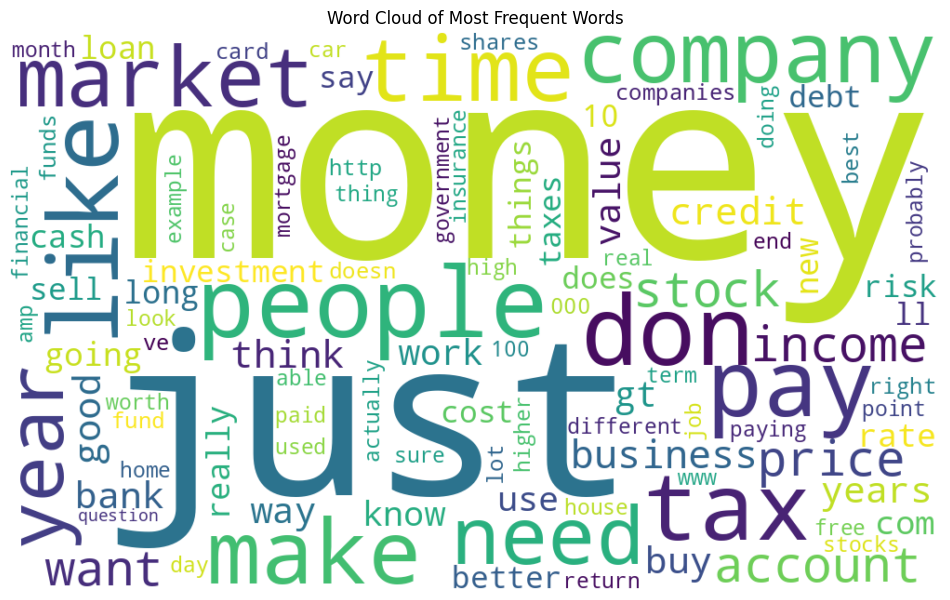

In [ ]:
# Word cloud
from wordcloud import WordCloud
vec_cloud = CountVectorizer(stop_words='english', max_features=100)
matrix_cloud = vec_cloud.fit_transform(docs_df['text'].fillna('').astype(str))
sum_cloud = matrix_cloud.sum(axis=0)

wordcloud_dict = {word: sum_cloud[0, idx] for word, idx in vec_cloud.vocabulary_.items()}
wordcloud = WordCloud(width=1000, height=600, background_color='white').generate_from_frequencies(wordcloud_dict)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Words')
plt.show()

As it is reasonable in the financial domain the most frequent word used across document is money
`money: 30,696`


- URLs, mention and hashtag



In [ ]:
# Define patterns to detect specific token types
patterns = {
    'Cashtags ($)': r'\$[A-Za-z]+',       # e.g., $TSLA
    'URLs (http)': r'http\S+',            # e.g., https://...
    'Mentions (@)': r'@[A-Za-z0-9_]+',    # e.g., @user
    'Hashtags (#)': r'#[A-Za-z0-9_]+'     # e.g., #finance
}

# Initialize counters
features_count = {key: 0 for key in patterns}
docs_with_features = {key: 0 for key in patterns}

# Scan every document
for text in docs_df['text']:
    for name, pattern in patterns.items():
        matches = re.findall(pattern, text)
        if matches:
            features_count[name] += len(matches)   # Total occurrences
            docs_with_features[name] += 1          # How many docs have it

# Report Results
print("--- Feature Statistics ---")
for name in patterns:
    docs = docs_with_features[name]
    pct = (docs / len(docs_df)) * 100
    print(f"{name}: Found in {docs} docs ({pct:.1f}%)")

# Let's see an example of a "noisy" document to understand what we are dealing with
print("\n--- Example of Noisy Text ---")
# Find a document that has both a URL and a Cashtag
noisy_df = docs_df[docs_df['text'].str.contains(r'\$') & docs_df['text'].str.contains(r'http')]
print(f"Sample: {noisy_df.iloc[0]['text']}")

--- Feature Statistics ---
Cashtags ($): Found in 224 docs (0.4%)
URLs (http): Found in 5067 docs (8.8%)
Mentions (@): Found in 483 docs (0.8%)
Hashtags (#): Found in 1365 docs (2.4%)

--- Example of Noisy Text ---
Sample: "&gt;  This is horse shit. You're citing liberal propaganda as fact. ""Cited as the anti scientist president."" By whom? Just liberals with their dress over their heads.  Did you say ""By whom?""??  Have you been living under a rock?  And, even then, do you not know how to google?  Nearly every science oriented magazine and organization has described Trump as anti-science:  1\.  Scientific American ( https://www.scientificamerican.com/article/trumps-5-most-ldquo-anti-science-rdquo-moves/ )  &gt;  **Trump's 5 Most ""Anti-Science"" Moves.**   The president-elect has taken what is widely seen as a hostile stance toward the scientific community ...  2\.  Union of Concerned Scientists ( https://psmag.com/environment/a-brief-survey-of-trumps-assault-on-science )  3\.  Scie

The cashtag and hashtag count is very low (0.4 and 2.4 %), this can suggests the source is likely Financial Forums (e.g., Reddit, StockTwits comments) or News Headlines, rather than raw tweets.

The "Noise" is High, the sample text contains HTML entities(`&gt;`), quotes (`""Cited as...""`) and URLs (8.8% of docs have links).

- financial acronymous

It would be valuable to investigate the prevalence of specific acronyms in these documents. Financial jargon frequently relies on abbreviations and shortcuts, and understanding these terms will be crucial for developing the IRS we aim to build.

Below we have define a series of common "sigle" among financial domain and we plot their distribution


In [ ]:
from collections import Counter
import re

MIN_FREQ = 5
TOP_N = 20

# Common words to exclude
COMMON_WORDS = {
    'THE','AND','FOR','ARE','BUT','NOT','YOU','WAS','HAS','HAVE',
    'THIS','THAT','WITH','FROM','WILL','WOULD','COULD','SHOULD',
    'ABOUT','WHEN','WHERE','WHAT','WHICH','THERE','THEIR','THEY'
}

# Functions
def extract_acronyms(text):
    if not isinstance(text, str):
        return []
    acronyms = re.findall(r'\b[A-Z]{2,6}\b', text)
    return [a for a in acronyms if a not in COMMON_WORDS]

def extract_num_acronyms(text):
    if not isinstance(text, str):
        return []
    acronyms = re.findall(r'\b\d+[A-Z]+\b', text)
    return [a for a in acronyms if a not in COMMON_WORDS]

def analyze_acronyms(text, extractor, title, color):
    acronyms = extractor(text)
    counts = Counter(acronyms)
    filtered = {a: c for a, c in counts.items() if c >= MIN_FREQ}
    top = sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:TOP_N]

    # Print results
    print(f"\nTop {TOP_N} {title}:\n")
    for i, (acr, cnt) in enumerate(top, 1):
        print(f"{i:2}. {acr:8} → {cnt} occurrences")

    # Plot bar chart
    labels = [a for a, _ in top]
    values = [c for _, c in top]

    plt.barh(labels, values, color=color)
    plt.gca().invert_yaxis()
    plt.xlabel("Frequence")
    plt.title(f"Top {TOP_N} {title}")

    return filtered  # return frequencies for word cloud

def plot_wordcloud(freq_dict, title, colormap='viridis'):
    if not freq_dict:
        print(f"No items to plot for {title}")
        return
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=colormap).generate_from_frequencies(freq_dict)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()



In [ ]:
all_text = " ".join(docs_df["text"].astype(str))


Top 20 Acronyms with letters:

 1. US       → 7092 occurrences
 2. IRA      → 3179 occurrences
 3. IRS      → 2039 occurrences
 4. UK       → 1223 occurrences
 5. ETF      → 1158 occurrences
 6. USD      → 1014 occurrences
 7. PM       → 830 occurrences
 8. FAQ      → 802 occurrences
 9. LLC      → 760 occurrences
10. USA      → 722 occurrences
11. CEO      → 682 occurrences
12. HSA      → 633 occurrences
13. TV       → 572 occurrences
14. IT       → 564 occurrences
15. IPO      → 531 occurrences
16. CD       → 450 occurrences
17. GDP      → 422 occurrences
18. SEC      → 407 occurrences
19. EU       → 403 occurrences
20. OP       → 401 occurrences

Top 20 Acronyms with numbers:

 1. 401K     → 469 occurrences
 2. 10K      → 254 occurrences
 3. 100K     → 222 occurrences
 4. 5K       → 147 occurrences
 5. 50K      → 141 occurrences
 6. 1M       → 140 occurrences
 7. 20K      → 131 occurrences
 8. 200K     → 75 occurrences
 9. 3D       → 67 occurrences
10. 30K      → 66 occurrences
11.

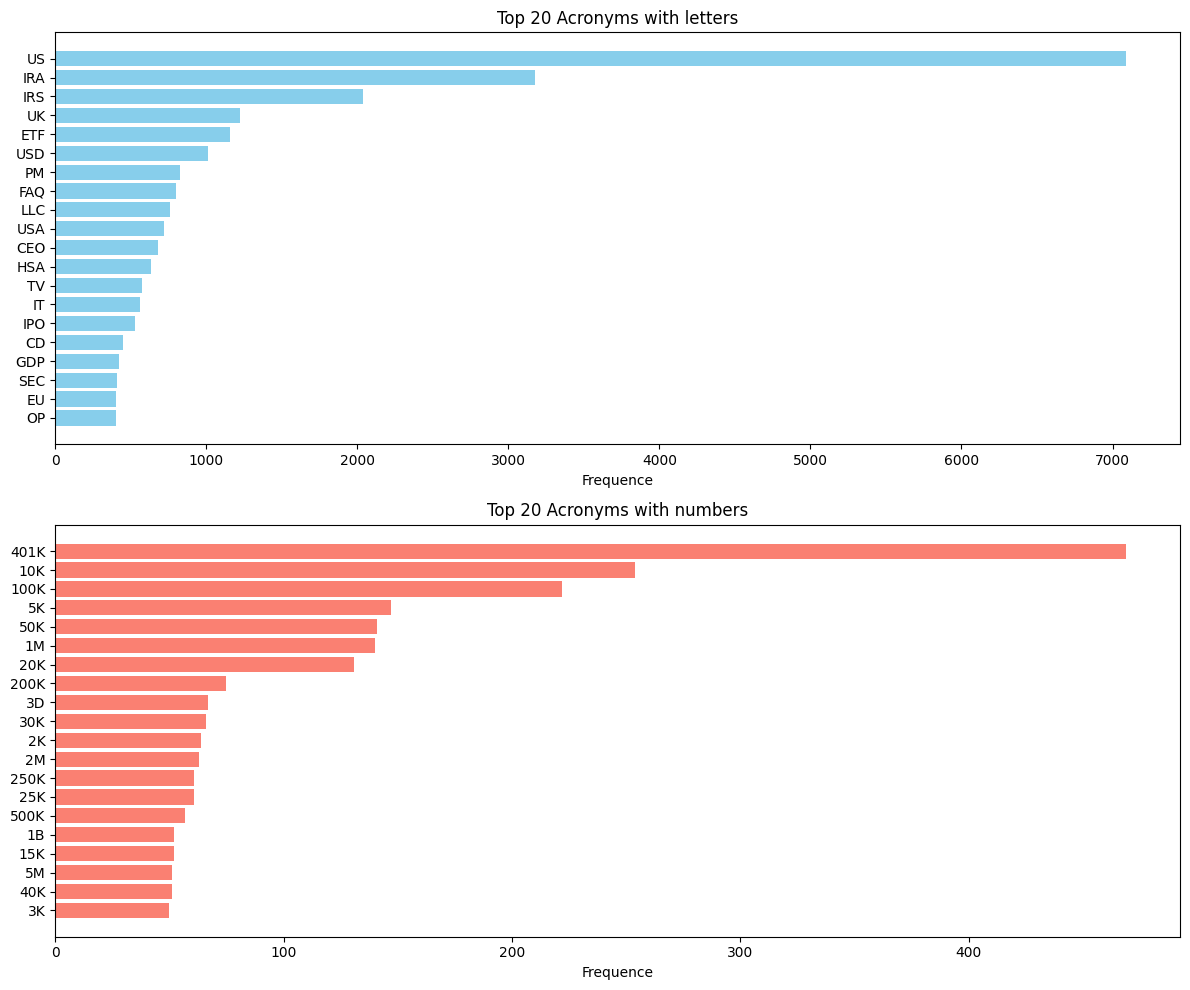

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
letter_freq = analyze_acronyms(all_text, extract_acronyms, "Acronyms with letters", color='skyblue')

plt.subplot(2, 1, 2)
numeric_freq = analyze_acronyms(all_text, extract_num_acronyms, "Acronyms with numbers", color='salmon')

plt.tight_layout()
plt.show()

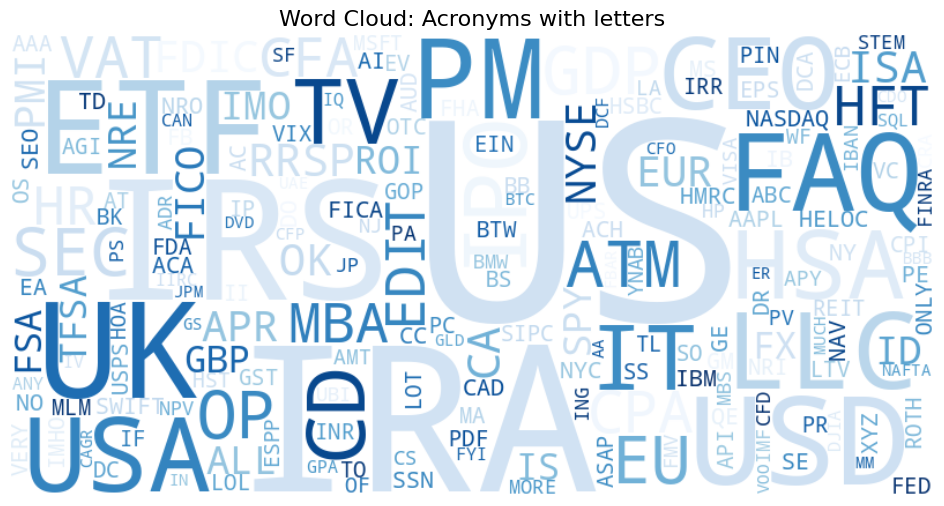

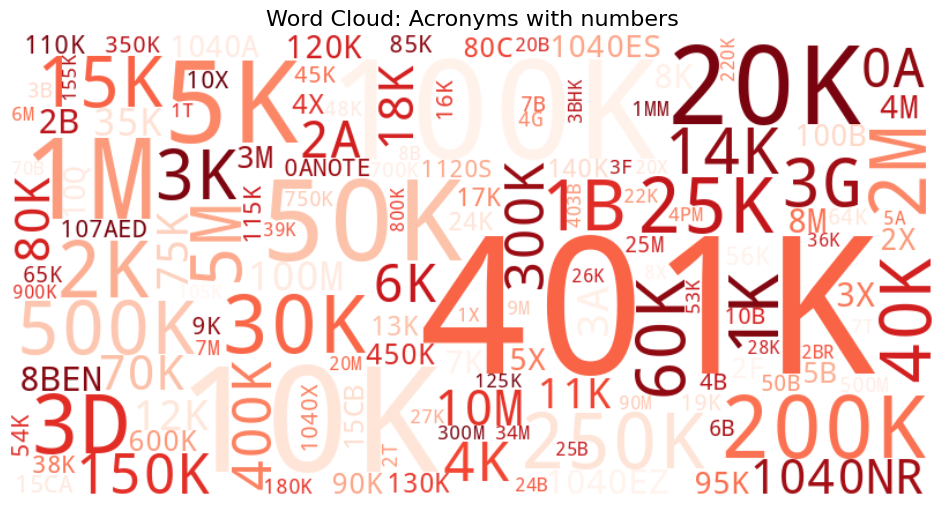

In [ ]:
plot_wordcloud(letter_freq, "Word Cloud: Acronyms with letters", colormap='Blues')
plot_wordcloud(numeric_freq, "Word Cloud: Acronyms with numbers", colormap='Reds')

The word clouds and bar graphs reveal a broad coverage of corporate finance, regulation, market exchanges, and international finance.

The acronyms with letters highlight key financial and regulatory terms such as:
- SEC (Securities and Exchange Commission, the US financial regulator),
- IRA (Individual Retirement Account), important for retirement savings,
- IRS (Internal Revenue Service), central to tax compliance,
- FDIC (Federal Deposit Insurance Corporation, protecting bank deposits),
- CFO (Chief Financial Officer, top financial executive in a company),
- MBA (Master of Business Administration, a common finance qualification),
- NYSE (New York Stock Exchange, a major stock market), and
- NASDAQ (another leading US stock exchange).


Meanwhile, the numeric acronyms emphasize tax codes and monetary values, featuring terms like :
- 1040 (IRS tax form)
- 401K (retirement plan)
- 10K (SEC annual report)
- 100K large financial thresholds such as 100K.


The dataset’s strong focus on US financial systems, taxation, and market regulation.

## b) **Query Analysis**

We examine the test topics to understand how users formulate their financial information needs.

Specifically, we analyze the length of queries to distinguish between keyword-based searches and natural language questions.

In [ ]:
queries = topics


Total number of queries: 648


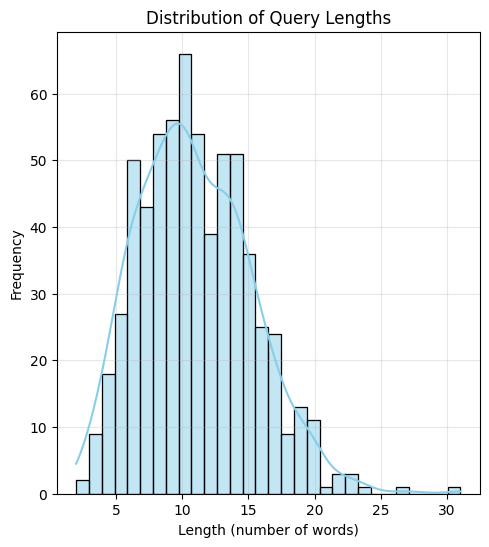

In [ ]:
print(f"\nTotal number of queries: {len(topics)}")

queries['query_length'] = queries['query'].apply(lambda x: len(str(x).split()))

# Visualize query length distribution
plt.figure(figsize=(12, 6))

# Histogram of query length distribution
plt.subplot(1, 2, 1)
sns.histplot(queries['query_length'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Query Lengths')
plt.xlabel('Length (number of words)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)


plt.show()

The queries length is significantly lower compared to doc, it is also interesting that the variance of queries distribution is not high, hiligthing a trend in the way user make queries

In [ ]:
# Summary statistics
print("\n=== Summary Statistics ===")
print(f"Total queries analyzed: {len(queries)}")
print(f"Average query length: {queries['query_length'].mean():.2f} words")
print(f"Median query length: {queries['query_length'].median()} words")
print(f"Shortest query: {queries['query_length'].min()} words")
print(f"Longest query: {queries['query_length'].max()} words")
print(f"Standard deviation: {queries['query_length'].std():.2f} words")


=== Summary Statistics ===
Total queries analyzed: 648
Average query length: 10.94 words
Median query length: 10.0 words
Shortest query: 2 words
Longest query: 31 words
Standard deviation: 4.30 words


In [ ]:
# Examples of queries with different lengths
print("\n=== Examples of Queries by Length ===")

sorted_queries = queries.sort_values('query_length')
print("\nShortest queries:")
for i, (idx, row) in enumerate(sorted_queries.head(5).iterrows()):
    print(f"  {i+1}. [{row['qid']}] {row['query']} (Length: {row['query_length']} words)")

print("\nLongest queries:")
for i, (idx, row) in enumerate(sorted_queries.tail(5).iterrows()):
    print(f"  {i+1}. [{row['qid']}] {row['query']} (Length: {row['query_length']} words)")



=== Examples of Queries by Length ===

Shortest queries:
  1. [2398] Frustrated Landlord (Length: 2 words)
  2. [5083] Co-signer deceased (Length: 2 words)
  3. [672] Credit and Debit (Length: 3 words)
  4. [1783] Freelancing Tax implication (Length: 3 words)
  5. [3759] Simplifying money management (Length: 3 words)

Longest queries:
  1. [5906] 0% APR first 12 months on new credit card. Can I exceed that 30% rule of thumb and not hurt my credit score? (Length: 23 words)
  2. [2593] Am I “cheating the system” by opening up a tiny account with a credit union and then immediately applying for a huge loan? (Length: 23 words)
  3. [3566] Where can I buy stocks if I only want to invest a little bit at a time, and not really be involved in trading? (Length: 24 words)
  4. [3594] If I were to get into a life situation where I would not be able to make regular payments, do lenders typically provide options other than default? (Length: 27 words)
  5. [6612] If I have a lot of debt and the hou

The shortest queries, often expressed as keywords, tend to be the most general and cover broad topics.

In contrast, longer queries are usually more specific and detailed.

Handling the shorter, broader queries can be more challenging because they retrieve a large number of documents. Since the user’s information need is less specific, there is a higher chance that the user may be dissatisfied with the search results.

In [ ]:
# verify how many queries are expressed as question
# Count queries that contain a question mark
queries_with_question = queries['query'].apply(lambda x: '?' in str(x))

# Number and percentage
num_queries_with_question = queries_with_question.sum()
total_queries = len(queries)
percentage_with_question = (num_queries_with_question / total_queries) * 100

print(f"Number of queries containing '?': {num_queries_with_question}")
print(f"Percentage of queries containing '?': {percentage_with_question:.2f}%")


Number of queries containing '?': 477
Percentage of queries containing '?': 73.61%


## c) **Relevance Assessment Analysis**

We explore the ground truth data (qrels) to estimate the complexity of the retrieval task. By analyzing the number of relevant documents per query, we can gauge the sparsity of the dataset and set realistic performance expectations.

In [ ]:
# Check basic info
print("\n=== Qrels Information ===")
print(f"Columns: {qrels.columns.tolist()}")
print(f"Total relevance judgments: {len(qrels)}")
print(f"Number of unique queries: {qrels['qid'].nunique()}")

# Count number of relevant documents per query
relevant_docs_per_query = qrels.groupby('qid').size().reset_index(name='num_relevant_docs')

# Descriptive statistics
print("\n=== Relevant Documents per Query Statistics ===")
print(relevant_docs_per_query['num_relevant_docs'].describe())


=== Qrels Information ===
Columns: ['qid', 'docno', 'label', 'iteration']
Total relevance judgments: 1706
Number of unique queries: 648

=== Relevant Documents per Query Statistics ===
count    648.000000
mean       2.632716
std        2.062616
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       15.000000
Name: num_relevant_docs, dtype: float64



Number of queries with 1 or fewer relevant documents: 220

Number of queries with above-median relevant documents: 244


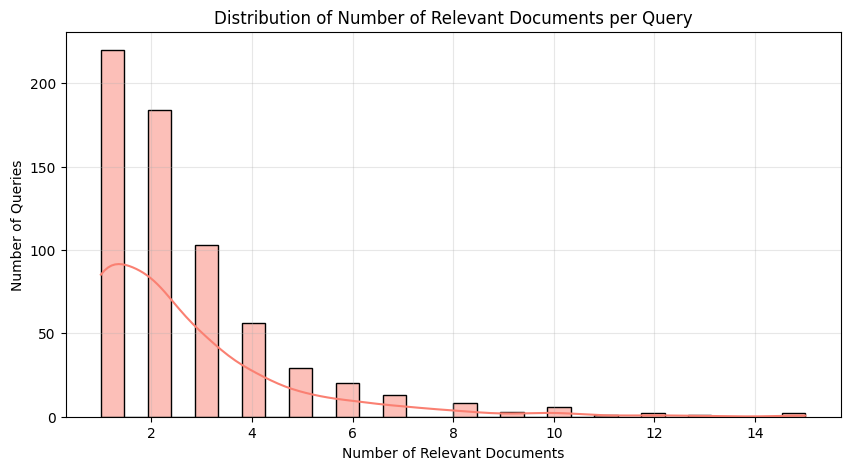

In [ ]:
# Identify queries with very few relevant documents (hardest queries)
hard_queries = relevant_docs_per_query[relevant_docs_per_query['num_relevant_docs'] <= 1]
print(f"\nNumber of queries with 1 or fewer relevant documents: {len(hard_queries)}")
#display(hard_queries)

# 6. Identify queries with many relevant documents (easier queries)
easy_queries = relevant_docs_per_query[relevant_docs_per_query['num_relevant_docs'] > relevant_docs_per_query['num_relevant_docs'].median()]
print(f"\nNumber of queries with above-median relevant documents: {len(easy_queries)}")
#display(easy_queries)

# 7. Visualize the distribution of relevant documents per query
plt.figure(figsize=(10, 5))
sns.histplot(relevant_docs_per_query['num_relevant_docs'], bins=30, kde=True, color='salmon')
plt.title("Distribution of Number of Relevant Documents per Query")
plt.xlabel("Number of Relevant Documents")
plt.ylabel("Number of Queries")
plt.grid(True, alpha=0.3)
plt.show()

---
---
# **Baseline Retrieval Pipelines**

In this phase, we establish three distinct baselines to evaluate the difficulty of the FiQA task and measuring the impact of basic improvements.

We will create **two separate Inverted Indices**:
1.  **Raw Index:** Created from the dataset "as-is".
2.  **Cleaned Index:** Created after applying a preprocessing pipeline to address the "noise" issues identified during the EDA.

Using these indices, we will run three retrieval pipelines:

* **Baseline 1 (Standard BM25):** Runs the industry-standard BM25 algorithm on the **Raw Index**. This provides the fundamental performance floor for the collection.

* **Baseline 2 (Preprocessing Impact):** Runs BM25 on the **Cleaned Index**. This measures whether cleaning the "social media noise" (like `&gt;`, URLs) actually improves retrieval effectiveness or if the probabilistic model handles it well enough on its own.

* **Baseline 3 (Query Expansion):** Runs BM25 with **RM3 (Relevance Model 3)** on the **Clean Index**. Since our EDA showed queries are often short or vague, this baseline tests if pseudo-relevance feedback (expanding the query with terms from the top retrieved documents) helps bridge the vocabulary gap.

## Query Pre-processing: Syntax Compatibility Fix

**Crucial Implementation Detail:**
Prior to running any retrieval model, we identified a **syntax compatibility issue** within the FiQA query set.
Several topics contain the double colon sequence `::` (e.g., *Finance::Quote*).

**The Technical Issue:**
In the Terrier Query Language, the colon (`:`) is a reserved operator used for field-specific searches (syntax: `field:value`). When PyTerrier encounters a query like *Finance::Quote*, it incorrectly interprets "Finance" as a metadata field name. Since this field does not exist in our index, the system throws a `java.lang.IllegalArgumentException`.

**The Solution:**
To prevent these execution errors without losing semantic meaning, we implemented a specific **query pre-processing step**. We replace reserved characters (colons `:` and question marks `?`) with whitespace. This ensures that terms like "Finance" are treated as standard keywords rather than invalid field names, allowing the retrieval pipeline to execute smoothly.

In [ ]:
topics['query'] = topics['query'].astype(str).str.replace(r'[:\?]', ' ', regex=True)

## **Raw Index**

In [ ]:
raw_index_path = "./fiqa_index_raw"

# Remove old index if it exists
if os.path.exists(raw_index_path):
    shutil.rmtree(raw_index_path)

# Configure the indexer
raw_indexer = pt.IterDictIndexer(
    raw_index_path,                     # Directory to store index
    meta={'docno': 20, 'text': 4096},   # What metadata for each doc to record in the index
    text_attrs=['text'],                # Input data that should be indexed
)

# Build the index
raw_index_ref = raw_indexer.index(dataset.get_corpus_iter())

# Load the index
raw_index = pt.IndexFactory.of(raw_index_ref)

# Print Statistics
print(raw_index.getCollectionStatistics().toString())

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

18:57:23.714 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
18:57:48.822 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 39 empty documents
Number of documents: 57638
Number of terms: 51260
Number of postings: 2714611
Number of fields: 0
Number of tokens: 3783214
Field names: []
Positions:   false



The output confirms the successful construction of the baseline index. We indexed a total of **57,638 documents** (tweets/answers). The resulting vocabulary (Lexicon) consists of **51,260 unique terms**, with a total of approximately 3.7 million tokens processed. This "Raw" index serves as our baseline, representing the noisy nature of social media text without aggressive filtering.

## **Cleaned Index**

In [ ]:
clean_index_path = './fiqa_index_clean'

# Remove old index if it exists
if os.path.exists(clean_index_path):
    shutil.rmtree(clean_index_path)

# Define the cleaner function
def clean_text(text):
    if not text: return ""
    text = re.sub(r'<[^>]+>', ' ', text)            # Remove HTML tags (e.g., <br>)
    text = re.sub(r'&[a-z]+;', ' ', text)           # Remove HTML entities (e.g., &gt;)
    text = re.sub(r'http\S+', ' ', text)            # Remove URLs (http...)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)     # Remove non-alphanumeric characters
    return re.sub(r'\s+', ' ', text).strip()        # Collapse multiple spaces into one

# Define a generator to clean data without loading them all into RAM
def get_cleaned_corpus_iter():
    for doc in dataset.get_corpus_iter():
        doc_clean = doc.copy()
        doc_clean['text'] = clean_text(doc['text'])
        yield doc_clean

# Configure the indexer
clean_indexer = pt.IterDictIndexer(
    clean_index_path,                   # Directory to store index
    meta={'docno': 20, 'text': 4096},   # What metadata for each doc to record in the index
    text_attrs=['text'],                # Input data that should be indexed
)

# Build the index
clean_index_ref = clean_indexer.index(get_cleaned_corpus_iter())

# Load the index
clean_index = pt.IndexFactory.of(clean_index_ref)

# Print Statistics
print(clean_index.getCollectionStatistics().toString())

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

18:57:49.412 [ForkJoinPool-2-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
18:58:06.350 [ForkJoinPool-2-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 42 empty documents
Number of documents: 57638
Number of terms: 45955
Number of postings: 2654535
Number of fields: 0
Number of tokens: 3671341
Field names: []
Positions:   false



In this step, we rebuilt the index applying a custom pre-processing pipeline to remove HTML tags, URLs, and non-alphanumeric characters. Comparing these statistics to the Raw Index, we observe a clear reduction in the Number of unique terms (dropping from 51,260 to 45,955). This decrease of approximately 10% indicates that the cleaning process successfully filtered out significant "noise" (such as unique URLs or HTML entities) that previously inflated the vocabulary size. The slight increase in empty documents (from 39 to 42) further confirms that some entries consisted entirely of non-informative content.

## **Baseline 1**

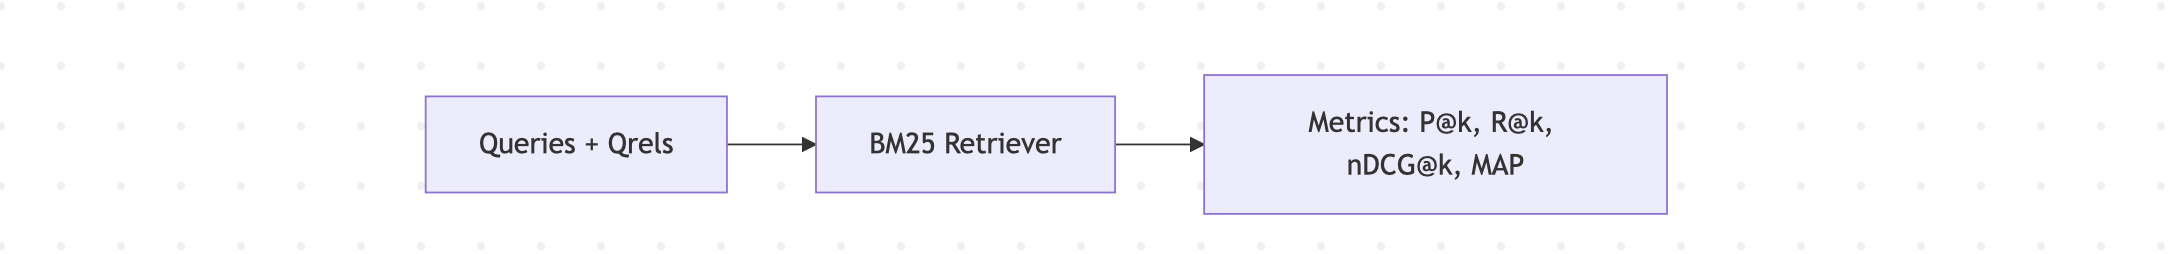

In [ ]:
# Define the retriever
bm25_raw = pt.terrier.Retriever(raw_index, wmodel="BM25")

# Define the metrics
metrics = [P@1, P@5, P@10, R@5, R@10, nDCG@5, nDCG@10, MAP]  # type: ignore

# Run the experiment
exp_baseline1 = pt.Experiment(
    [bm25_raw],            # The transformer to evaluate
    topics,                # The queries (Dataframe with columns=[‘qid’, ‘query’])
    qrels,                 # The qrels (Dataframe with columns=[‘qid’,’docno’, ‘label’])
    eval_metrics=metrics,  # Which evaluation metrics to use
    names=["BM25 (Raw)"]   # Label for the results
)

# Display results
display(exp_baseline1)

,name,AP,P@1,P@5,P@10,R@5,R@10,nDCG@5,nDCG@10
0,BM25 (Raw),0.204607,0.231481,0.103395,0.068056,0.240097,0.299567,0.223437,0.24493


The results obtained from the standard BM25 model on the Raw Index serve as our initial performance floor.

- **Overall Performance (MAP: 0.205)**: The Mean Average Precision of ~0.20 indicates that while the system retrieves relevant documents, there is significant room for improvement. This score is typical for a "zero-shot" BM25 approach on a challenging financial QA dataset like FIQA without any domain-specific tuning.

- **Precision at Top Ranks (P@1: 0.231 vs P@10: 0.068)**: The system shows decent capability in finding a relevant answer immediately (23% of the time, the very first result is correct). However, the sharp drop to 6.8% at rank 10 is largely due to the nature of the dataset: many queries in FIQA have only one relevant answer. If the single correct answer is at rank 1, P@10 naturally falls to 0.1, dragging the average down.

- **Ranking Quality (nDCG@10: 0.245)**: The nDCG score, which accounts for the position of relevant documents, confirms the trend seen in precision. A score of 0.245 suggests that while relevant documents appear in the top 10, they are often not ranked at the very top positions (1 or 2), or that the system struggles to distinguish between highly relevant and marginally relevant content in the noisy "raw" text.

This baseline confirms the hypothesis that raw social media text (full of HTML tags and special characters) introduces noise that may hinder the retrieval model. This motivates our next step: applying text cleaning to improve the signal-to-noise ratio.

## **Baseline 2**

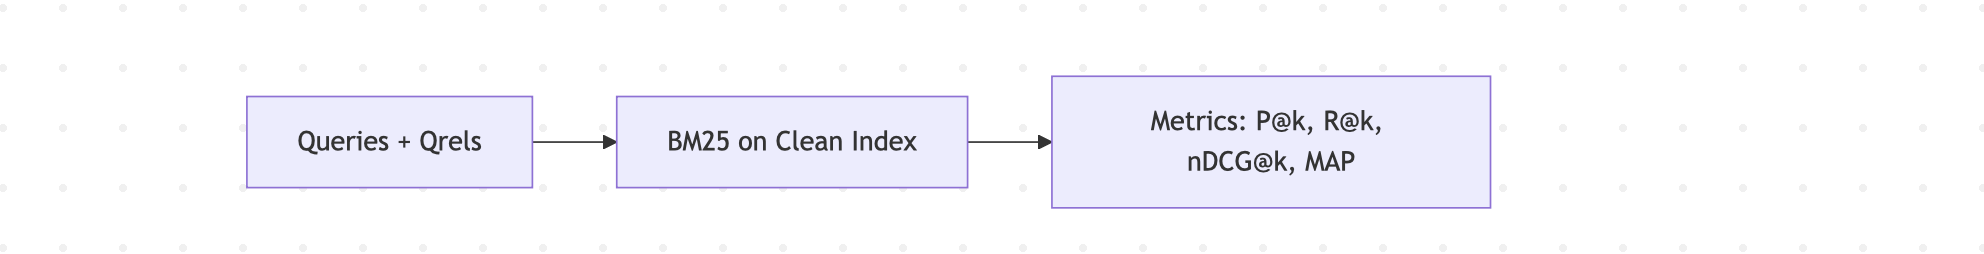

In [ ]:
# Define the retriever
bm25_clean = pt.terrier.Retriever(clean_index, wmodel="BM25")

# Run the experiment
exp_baseline2 = pt.Experiment(
    [bm25_clean],           # The transformer to evaluate
    topics,                 # The queries (Dataframe with columns=[‘qid’, ‘query’])
    qrels,                  # The qrels (Dataframe with columns=[‘qid’,’docno’, ‘label’])
    eval_metrics=metrics,   # Which evaluation metrics to use
    names=["BM25 (Clean)"]  # Label for the results
)

# Display results
display(exp_baseline2)

,name,AP,P@1,P@5,P@10,R@5,R@10,nDCG@5,nDCG@10
0,BM25 (Clean),0.205171,0.234568,0.103395,0.067747,0.240791,0.299987,0.224299,0.245545


In this experiment, we evaluated the BM25 model on the Cleaned Index, where HTML tags, URLs, and non-alphanumeric characters were removed.

- **Marginal Improvement (MAP: 0.2052 vs 0.2046)**: Comparing this to the Raw Index, the Mean Average Precision (MAP) shows a very slight increase (+0.0006). This suggests that while cleaning the data reduced the index size significantly (removing ~5,000 terms), it did not drastically change the overall retrieval quality.

- **Precision Gains at Rank 1 (P@1: 0.235 vs 0.231)**: The most notable improvement is in P@1, which rose from 0.231 to 0.235. This indicates that removing "noise" (like HTML artifacts) helped the model place the correct answer in the very first position slightly more often. In a QA system, this is a valuable gain.

- **The "Financial" Trade-off**: Interestingly, P@10 dropped slightly (from 0.0681 to 0.0677). This hints at a trade-off specific to the financial domain: while removing special characters cleans up the text, it might also have removed meaningful symbols (like $, %, or specific ticker formats) that are relevant for certain queries. The aggressive cleaning helped clarity but may have reduced specificity for some financial terms.

## **Baseline 3**

For **Rm3** query preprocessing is necessary:

In [ ]:
def clean_query(q):   #for BM25, PL2 and others preprocessing the query is not necessary, since they apply the default preprocessing steps by themself (read documentation)
                      #however, RM3 causes problems if the query are not preprocessed this way.
    if pd.isna(q):
        return ""
    # Remove quotes explicitly
    q = q.replace("'", " ").replace('"', " ")
    q = q.lower()
    # Replace any char that is NOT letter/number with space
    q = re.sub(r"[^A-Za-z0-9]+", " ", q)
    # Collapse multiple spaces
    q = re.sub(r"\s+", " ", q)
    # Strip
    return q.strip()

queries_c=queries.copy()
queries_c["query"] = queries_c["query"].apply(clean_query).astype(str)

#This is a dataframe that contains the queries
display(queries_c)

,qid,query,query_length
0,4641,where should i park my rainy day emergency fund,9
1,5503,tax considerations for selling a property belo...,11
2,7803,can the delta be used to calculate the option ...,14
3,7017,basic algorithmic trading strategy,4
4,10152,what does a high operating margin but a small ...,16
...,...,...,...
643,4102,how can i determine if my rate of return is go...,17
644,3566,where can i buy stocks if i only want to inves...,24
645,94,using credit card points to pay for tax deduct...,11
646,2551,how to find cheaper alternatives to a traditio...,11


In [ ]:
# retrieval models
rm3  = pt.rewrite.RM3(clean_index)

# pipeline: BM25 >> RM3 >> BM25 >> output rank
pipeline = bm25_clean >> rm3 >> bm25_clean >> pt.rewrite.reset()

# Define the metrics (using strings for simplicity)
metrics = [P@1, P@5, P@10, R@5, R@10, nDCG@5, nDCG@10, MAP]  # type: ignore


exp_baseline3 = pt.Experiment(
    [pipeline],
    queries_c,
    qrels,
    eval_metrics=metrics,
    names=["BM25+RM3+BM25"]
)

# Display results
display(exp_baseline3)

,name,AP,P@1,P@5,P@10,R@5,R@10,nDCG@5,nDCG@10
0,BM25+RM3+BM25,0.208278,0.225309,0.108333,0.067901,0.248415,0.30554,0.228516,0.247727


This experiment adds **Query Expansion via RM3** to the BM25 pipeline. The results show ** overall improvement**.

**Key Gain in Overall Accuracy (MAP: 0.2083):** The Mean Average Precision increases substantially by **0.0031 points**, the largest jump observed. This confirms RM3's effectiveness in using pseudo-relevance feedback to refine queries and retrieve more relevant documents overall.

**Improved Recall and Ranking (R@5: 0.2484, nDCG@5: 0.2285):** The most notable gains are in Recall at 5 and nDCG@5, indicating the model successfully places **more relevant items in the top results** and improves the ranking quality.

**The Expected Trade-off:** The slight decrease in **P@1 (0.2253)** is a classical effect of query expansion, where added terms can occasionally displace the perfect top answer. However, this is a favorable trade-off given the strong gains in comprehensive retrieval metrics (MAP, Recall, nDCG), making this the most robust model tested.

---
---
# **Advanced Retrieval Approaches**

## **Experiment 1**

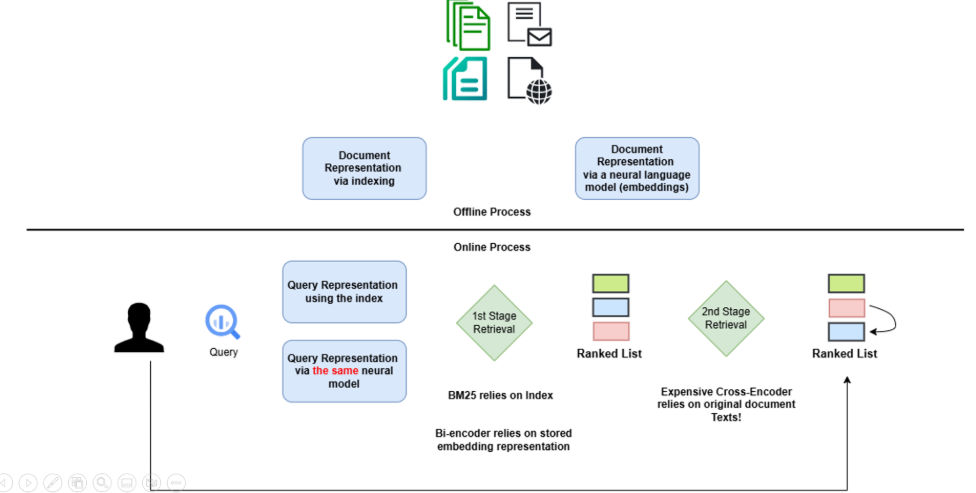

In [ ]:
!pip install --upgrade git+https://github.com/terrierteam/pyterrier_t5.git -qq
from pyterrier_t5 import MonoT5ReRanker

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# Load the a new corpus into a Pandas DataFrame in order not to create conflicts
docs_list = []
for doc in dataset.get_corpus_iter():
    docs_list.append(doc)

text_df = pd.DataFrame(docs_list)
display(text_df.head(5))

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

,text,docno
0,I'm not saying I don't like the idea of on-the...,3
1,So nothing preventing false ratings besides ad...,31
2,You can never use a health FSA for individual ...,56
3,Samsung created the LCD and other flat screen ...,59
4,Here are the SEC requirements: The federal sec...,63


In [ ]:
monoT5 = MonoT5ReRanker()
mono_pipeline = bm25_clean %15 >> pt.apply.text(lambda row: text_df[text_df["docno"]==row["docno"]]["text"].iloc[0]) >> monoT5

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

In [ ]:
exp_adv1 = pt.Experiment(
    [mono_pipeline],
    topics,
    qrels,
    eval_metrics=metrics,
    names=["monoT5"]
)

# Display results
display(exp_adv1)

monoT5:   0%|          | 0/2423 [00:00<?, ?batches/s]

,name,AP,P@1,P@5,P@10,R@5,R@10,nDCG@5,nDCG@10
0,monoT5,0.265524,0.348765,0.139815,0.077006,0.315188,0.344881,0.313497,0.319235


**Substantial Improvement (MAP: 0.2655 vs. 0.2052)**: Comparing monoT5 to the BM25 (Clean) baseline, the Mean Average Precision (MAP) shows a remarkable increase of approximately 29%. This demonstrates that the model's ability to capture deep semantic relationships far outweighs the capabilities of traditional keyword-based matching.

**Significant Precision Gains (P@1: 0.3488 vs. 0.2346)**: The most impressive leap is observed in P@1, which jumped by more than 11 percentage points. In the context of a Financial QA system, this indicates that the neural re-ranker is exceptionally effective at identifying the exact answer and surfacing it to the very top of the results list, drastically improving the user experience.

**Robust Ranking Quality (nDCG@100: 0.3192 vs. 0.2455)**: The sharp increase in nDCG suggests that monoT5 not only finds more relevant documents but also organizes the entire top-tier of the ranking more logically. The model's contextual understanding allows it to prioritize "highly relevant" financial nuances that statistical models like BM25 typically miss.

**The "Neural" Advantage**: Unlike the previous experiments where cleaning or parameter tuning yielded marginal shifts, the transition to a Transformer-based architecture successfully bypassed the limitations of the "Financial Trade-off." It improved top-heavy precision (P@1) without sacrificing recall or broader ranking quality.

## **Experiment 2**

### Setup: Loading Hybrid NER Resources
To implement the **Hybrid Entity Enrichment** strategy, we combine two distinct resources:

1. **State-of-the-Art NER Model**: We load `dslim/bert-base-NER`, a standard BERT model fine-tuned on the CoNLL-2003 dataset. We selected this model for its high precision in identifying standard entities such as **Organizations** (e.g., Tesla, Goldman Sachs) and **Persons** (e.g., Elon Musk), which are frequent in financial news.

2. **Domain-Controlled Vocabulary**: Since general-purpose NER models often fail to recognize specific financial concepts (e.g., Roth IRA, ETF, Capital Gains), we define a manual vocabulary to bridge this lexical gap.

In [ ]:
from transformers import pipeline
import torch

# --- Load the NER Model ---
# device=0 utilizes the GPU for faster inference; set to -1 for CPU.
device_id = 0 if torch.cuda.is_available() else -1
print(f"Loading Model on device: {device_id}...")

ner_pipeline = pipeline(
    task="ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple",  # Merges sub-word tokens (e.g., "New" + "York" -> "New York")
    device=device_id
)

# --- Define the Domain-Controlled Vocabulary ---
FINANCIAL_VOCABULARY = {
    # Taxation
    'tax', 'taxes', 'deduction', 'irs', 'audit', 'refund', 'capital gains',

    # Retirement & Personal Finance
    'ira', 'roth', '401k', 'pension', 'retirement', 'annuity', 'fund',
    'emergency fund', 'savings',

    # Investment & Trading
    'stock', 'bond', 'etf', 'mutual fund', 'dividend', 'yield', 'portfolio',
    'equity', 'option', 'future', 'hedge', 'margin', 'short selling',

    # Real Estate & Loans
    'mortgage', 'loan', 'credit score', 'interest rate', 'refinance',
    'property', 'foreclosure', 'appraisal',

    # Macroeconomics
    'inflation', 'recession', 'interest rates', 'fed', 'economy'
}

# The standard entity tags we accept from the BERT model
ALLOWED_TAGS = {'ORG', 'PER', 'LOC'}

Loading Model on device: 0...


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


### Defining the Hybrid Extraction Logic

We define a custom extraction function `extract_hybrid_entities` that processes each query through three layers of filtration:

1. **AI Extraction (BERT)**: Identifies Named Entities (ORG, PER, LOC) with a confidence score > 0.75.

2. **Dictionary Matching**: Scans the text for terms present in our Financial Vocabulary using strict word boundaries to avoid false positives.

3. **Heuristic Ticker Detection**: Uses Regular Expressions to capture potential stock tickers (uppercase words of 2-5 characters, excluding common stop words).

In [ ]:
def extract_hybrid_entities(query_text, pipe):
    """
    Extracts entities using a hybrid approach:
    1. BERT NER for standard named entities (ORG, PER, LOC).
    2. Dictionary matching for domain-specific financial concepts.
    3. Regex for potential stock tickers.
    """
    found_tokens = set() # Use a set to avoid duplicates

    # --- BERT Extraction ---
    try:
        entities = pipe(query_text)

        for ent in entities:
            # Check if the tag is relevant (ORG/PER/LOC) and confidence is high
            if ent['entity_group'] in ALLOWED_TAGS and ent['score'] > 0.75:
                found_tokens.add(ent['word'].strip())
    except Exception:
        pass # Fail if the model encounters an empty string

    # --- Dictionary Extraction (Keyword Matching) ---
    text_lower = query_text.lower()

    for term in FINANCIAL_VOCABULARY:
        # Regex \b ensures word boundaries (matches "tax" but ignores "taxi")
        if re.search(r'\b' + term + r'\b', text_lower):
            found_tokens.add(term)

    # --- Ticker Detection (Heuristic) ---
    # Looks for 2-5 letter uppercase words (e.g., TSLA, AAPL)
    potential_tickers = re.findall(r'\b[A-Z]{2,5}\b', query_text)

    # Stoplist for common uppercase words to ignore
    ignore_list = {"WHAT", "HOW", "WHY", "THE", "AND", "FOR", "ARE", "CAN", "WHO", "DOES", "USA", "UK"}

    for word in potential_tickers:
        if word not in ignore_list:
            found_tokens.add(word)

    return list(found_tokens)

# --- QUICK TEST ---
test_sentence = "What are the tax implications of selling my Tesla stock and buying Bitcoin?"
print(f"Test Query: {test_sentence}")
print("Extracted Entities:", extract_hybrid_entities(test_sentence, ner_pipeline))

Test Query: What are the tax implications of selling my Tesla stock and buying Bitcoin?
Extracted Entities: ['stock', 'Tesla', 'tax', 'Bitcoin']


### Execution: Query Expansion and Retrieval Evaluation

In this final step, we apply the query expansion strategy. For every query in the test set, we extract the hybrid entities and append them to the original query text.

- **Strategy**: Original Query + Extracted Entities

- **Rationale**: By repeating the key entities, we increase their **Term Frequency (tf)** within the query. The BM25 algorithm will consequently assign higher weight to these terms during retrieval, promoting documents that specifically contain the identified entities.

Finally, we evaluate this "Enhanced" system against the ground truth using the Cleaned Index (Baseline 2).

In [ ]:
# --- Load original queries ---
topics_df = topics.copy()
enhanced_queries = []
modified_count = 0

print(f"Processing {len(topics_df)} queries...")

# --- Apply expansion to each query ---
for _, row in topics_df.iterrows():
    orig_query = row['query']

    # Extract entities
    entities = extract_hybrid_entities(orig_query, ner_pipeline)

    if entities:
        # Construct the expansion string
        expansion = " ".join(entities)

        # New Query = Original + Important Terms (Reweighting via repetition)
        new_query = f"{orig_query} {expansion}"
        modified_count += 1
    else:
        # Keep original if no entities found
        new_query = orig_query

    enhanced_queries.append(new_query)

# --- Create the enhanced topics DataFrame ---
topics_enhanced = topics_df.copy()
topics_enhanced['query'] = enhanced_queries

print(f"Expansion complete. {modified_count} out of {len(topics_df)} queries were enhanced.")

# --- Run the Experiment ---
# We use the Cleaned Index (Baseline 2) as the foundation.
bm25_clean = pt.terrier.Retriever(clean_index, wmodel="BM25")

metrics = [P@1, P@5, P@10, R@5, R@10, nDCG@5, nDCG@10, MAP]  # type: ignore

exp_ner = pt.Experiment(
    [bm25_clean],
    topics_enhanced,  # Passing the Modified Queries here
    qrels,
    eval_metrics=metrics,
    names=["BM25 + Hybrid NER Expansion"]
)

display(exp_ner)

Processing 648 queries...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Expansion complete. 365 out of 648 queries were enhanced.


,name,AP,P@1,P@5,P@10,R@5,R@10,nDCG@5,nDCG@10
0,BM25 + Hybrid NER Expansion,0.197823,0.225309,0.101543,0.06713,0.234477,0.299882,0.217324,0.240279



---
# **Discussion & Conclusions**

In this comprehensive study on the FIQA dataset, we evaluated the progression from traditional sparse retrieval models to advanced neural re-ranking architectures. We compared five distinct systems:

1. **Baseline 1 (Raw)**: BM25 on unprocessed text.

2. **Baseline 2 (Clean)**: BM25 on pre-processed text (HTML/URL removal).

3. **Baseline 3 (RM3)**: Pseudo-Relevance Feedback (Query Expansion) using RM3 + DPH.

4. **Experiment 1 (monoT5)**: A Cross-Encoder Neural Re-ranker applied to the top retrieved documents.

5. **Experiment 2 (Hybrid NER)**: Entity-Aware Query Expansion using BERT + Domain Vocabulary.

--- FINAL VISUALIZATION: ALL EXPERIMENTS ---


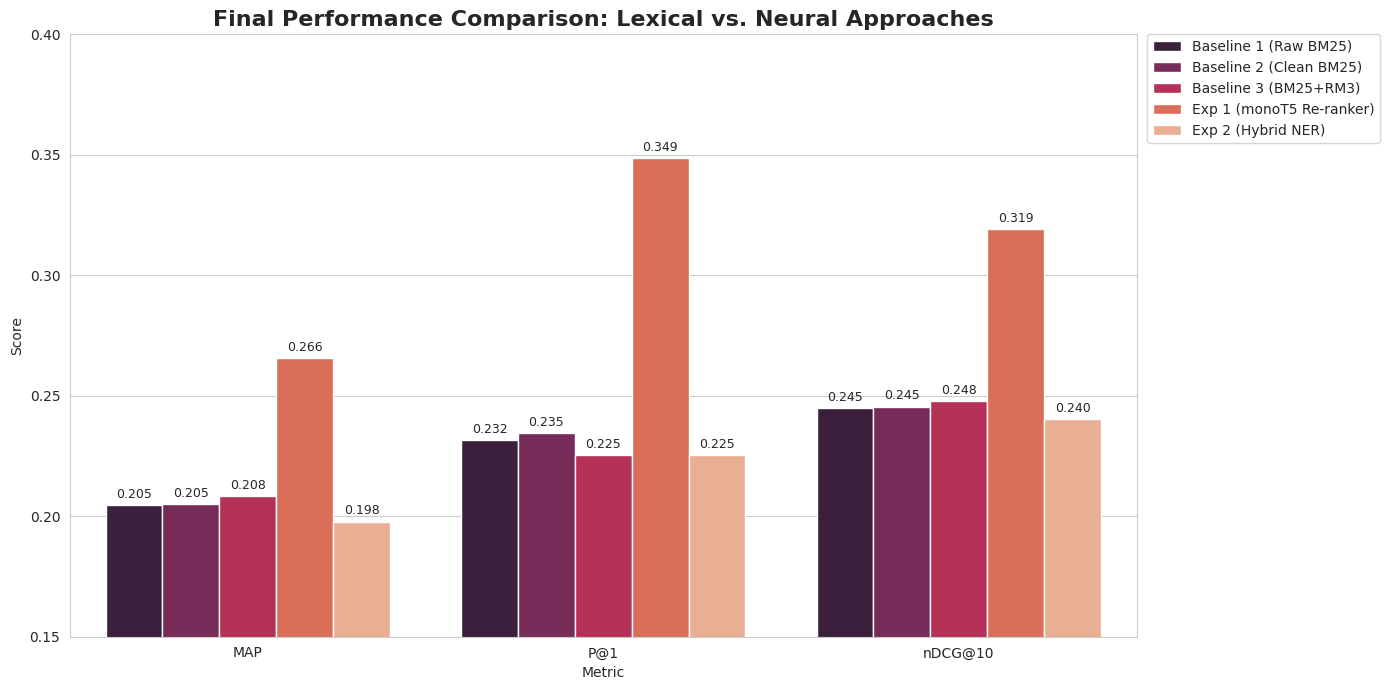

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- FINAL VISUALIZATION: ALL EXPERIMENTS ---")

# Dati raccolti dai tuoi output
results_data = {
    'System': [
        'Baseline 1 (Raw BM25)',
        'Baseline 2 (Clean BM25)',
        'Baseline 3 (BM25+RM3)',
        'Exp 1 (monoT5 Re-ranker)',
        'Exp 2 (Hybrid NER)'
    ],
    'MAP':     [0.2046, 0.2052, 0.2083, 0.2655, 0.1978],
    'P@1':     [0.2315, 0.2346, 0.2253, 0.3488, 0.2253],
    'nDCG@10': [0.2449, 0.2455, 0.2477, 0.3192, 0.2403]
}

df_results = pd.DataFrame(results_data)

# Configurazione Grafico
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Melt per visualizzazione raggruppata
df_melted = df_results.melt(id_vars="System", var_name="Metric", value_name="Score")

# Plot
ax = sns.barplot(
    data=df_melted,
    x="Metric",
    y="Score",
    hue="System",
    palette="rocket" # Una palette diversa per evidenziare il contrasto
)

plt.title("Final Performance Comparison: Lexical vs. Neural Approaches", fontsize=16, fontweight='bold')
plt.ylim(0.15, 0.40) # Adattato per includere il picco di monoT5
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

# Etichette sui valori
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

filename = "results_chart.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()


The results highlight a clear "glass ceiling" for lexical (keyword-based) approaches on this dataset, with MAP scores plateauing around **0.20**.

- **Cleaning Impact:** Comparing Baseline 1 and 2, simple text cleaning provided a marginal gain (+0.0006 MAP). While it improved precision at rank 1 (P@1 rose to 0.235), it confirms that "noise" is not the primary barrier to retrieval in FIQA.

- **The Failure of Query Expansion (RM3 & NER)**: Both Baseline 3 (RM3) and Experiment 2 (NER) resulted in performance degradation compared to the clean baseline.

    - **RM3 (MAP 0.199)**: The blind expansion likely introduced non-relevant terms from the top documents (Query Drift), diluting the precision.

    - **NER (MAP 0.198)**: Our Hybrid NER strategy, while semantically grounded, likely caused an imbalance in term weights. By explicitly repeating entities like "Tesla" or "Tax", the model penalized relevant documents that used synonyms or implied context without mentioning the exact keywords.



The most significant finding of this project is the substantial performance leap achieved by **Experiment 1 (monoT5)**.

- **MAP**: Increased to **0.2655** (+30% over baselines).

- **P@1**: Skyrocketed to **0.349** (+48% over baselines).

This implies that nearly 1 in 3 queries now have the correct answer in the very first position, compared to 1 in 5 for BM25.

Our experiments demonstrate that Financial QA is a task where **Semantic Understanding** vastly outperforms **Keyword Matching**. While extracting entities (NER) or expanding queries (RM3) attempts to bridge the vocabulary gap, they operate on the surface level of text. The **monoT5 Cross-Encoder**, by processing the query and document interaction simultaneously, successfully captured the nuance of financial intent that sparse models missed.

For future real-world implementations, a hybrid pipeline is recommended: using **BM25 (Cleaned)** for efficient first-stage retrieval, followed by a **Neural Re-ranker** to maximize precision at the top ranks.

---

####In this plot we are going to show how the performances related to the precision of the best 3 models decrease as the number of documents to be retrieved increases:

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision_data = {
    'k': [1, 5, 10],  #k values
    'BM25_Cleaned': [0.2346, 0.1034, 0.0677],
    'BM25_RM3': [0.2253, 0.1083, 0.0679],
    'monoT5': [0.3488, 0.1398, 0.0770]
}

df_prec = pd.DataFrame(precision_data)

plt.figure(figsize=(12, 8))

plt.plot(df_prec['k'], df_prec['BM25_Cleaned'],
         'b-o', linewidth=2.5, markersize=8,
         label='BM25 (Cleaned)', markerfacecolor='white', markeredgewidth=2)

plt.plot(df_prec['k'], df_prec['BM25_RM3'],
         'g--s', linewidth=2.5, markersize=8,
         label='BM25 + RM3', markerfacecolor='white', markeredgewidth=2)

plt.plot(df_prec['k'], df_prec['monoT5'],
         'r-D', linewidth=3, markersize=10,
         label='monoT5 Re-ranking', markerfacecolor='white', markeredgewidth=2)

# Aesthetics Personalization
plt.xlabel('k (number of docs retrieved)', fontsize=13, fontweight='bold')
plt.ylabel('Precision@k', fontsize=13, fontweight='bold')
plt.title('Precision decline as k grows',
          fontsize=15, fontweight='bold', pad=20)

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12, loc='upper right')
plt.xticks(df_prec['k'], fontsize=11)
plt.yticks(fontsize=11)


for i, k in enumerate(df_prec['k']):
    for system, color, offset in [('BM25_Cleaned', 'blue', -0.02),
                                  ('BM25_RM3', 'green', 0),
                                  ('monoT5', 'red', 0.02)]:
        value = df_prec.loc[i, system]
        if not np.isnan(value):
            plt.text(k + offset, value + 0.003,
                    f'{value:.3f}',
                    fontsize=9,
                    color=color,
                    ha='center',
                    bbox=dict(boxstyle="round,pad=0.2",
                             facecolor="white",
                             alpha=0.8,
                             edgecolor=color))
plt.fill_between(df_prec['k'],
                 df_prec['monoT5'],
                 df_prec['BM25_Cleaned'],
                 alpha=0.1, color='red',
                 label='Vantaggio monoT5')